In [ ]:
# importing the dependencies

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import numpy as np
from torch.optim import Adam
from torchvision.datasets.mnist import MNIST
from torch.utils.data import DataLoader



In [ ]:
# lets patch the images now , the first image where the image patch is conveted into vector representation
class Patch_Embedding(nn.Module):
  def __init__(self,dim_model , img_size , patch_size , n_color_channel):
    super().__init__()
    self.dim_model = dim_model
    self.img_size = img_size
    self.patch_size = patch_size
    self.n_color_channel = n_color_channel
    self.linear_projection = nn.Conv2d(
        in_channels=n_color_channel,
        out_channels=dim_model,
        kernel_size=patch_size,
        stride=patch_size
        )

  def forward(self,x):
    x = self.linear_projection(x)
    x = x.flatten(2)
    x = x.transpose(1,2)
    return x



### Now the third step :
1) Making the CLS ( classification token and adding positional embedding to the linear projection layer)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, seq_length):
        super().__init__()

        # learnable classification token
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        # learnable positional embeddings
        self.pos_embedding = nn.Parameter(
            torch.randn(1, seq_length + 1, d_model)
        )

    def forward(self, x):
        batch_size = x.shape[0]

        # expands the  CLS token for each image in batch
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)

        # adds CLS token to patch embeddings
        x = torch.cat((cls_tokens, x), dim=1)

        # Add positional embeddings
        x = x + self.pos_embedding

        return x

In [ ]:
# lets enter into the tranformer encoder block ; the attention mechanism acutally help sin themajor part of the project
class TransformerEncoder(nn.Module):
  def __init__(self, d_model, n_heads, r_mlp=4):
    super().__init__()
    self.d_model = d_model
    self.n_heads = n_heads

    # Sub-Layer 1 Normalization -> -> cleans the data for mha
    self.ln1 = nn.LayerNorm(d_model)

    # Multi-Head Attention
    self.mha = nn.MultiheadAttention(d_model, n_heads, batch_first=True)

    # Sub-Layer 2 Normalization -> cleans the data for mlp
    self.ln2 = nn.LayerNorm(d_model)

    # Multilayer Perception
    self.mlp = nn.Sequential(
        nn.Linear(d_model, d_model*r_mlp), #TAKES into higher dimension so squashed valued also can be checked
        nn.GELU(), # using gelu instead of relu because relu is non differentiable at 0
        nn.Linear(d_model*r_mlp, d_model)
    )

  def forward(self, x):
    # after mha -> helps in residual connection
    attn_output, _ = self.mha(self.ln1(x), self.ln1(x), self.ln1(x))
    out = x + attn_output


    # Residual Connection After Sub-Layer 2
    out = out + self.mlp(self.ln2(out))

    return out

In [ ]:
class ViT(nn.Module):

    def __init__(self, ch, img_size, patch_size, d_model, n_heads, n_layers, n_classes):
        super().__init__()

        # convert image into patch embeddings
        self.patch_embed = Patch_Embedding(d_model, img_size, patch_size, ch)

        # calculating how many patches we get from the image
        seq_len = (img_size // patch_size) ** 2

        # add positional info and cls token so transformer know order
        self.pos_enc = PositionalEncoding(d_model, seq_len)

        # stacking multiple transformer encoder layers
        self.transformer_stack = nn.Sequential(*[
            TransformerEncoder(d_model, n_heads) for _ in range(n_layers)
        ])

        # final head for classification
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(d_model),   # normalize before prediction
            nn.Linear(d_model, n_classes)  # map features to class scores
        )

    def forward(self, x):

        # turning image patches into embedding vectors
        x = self.patch_embed(x)

        # adding positional encoding and class token
        x = self.pos_enc(x)

        # passing tokens through transformer layers
        x = self.transformer_stack(x)

        # taking the first token which represent whole image
        cls_token_final = x[:, 0]

        # final prediction from cls token
        return self.mlp_head(cls_token_final)

In [ ]:
d_model = 64
n_classes = 10
img_size = 28
patch_size = 7
n_channels = 1
n_heads = 8
n_layers = 3
batch_size = 128
epochs = 5
alpha = 0.005

In [ ]:
transform = T.Compose([
  T.Resize(img_size),
  T.ToTensor()
])

train_set = MNIST(
  root="./../datasets", train=True, download=True, transform=transform
)
test_set = MNIST(
  root="./../datasets", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_set, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_set, shuffle=False, batch_size=batch_size)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device, f"({torch.cuda.get_device_name(device)})" if torch.cuda.is_available() else "")

transformer = ViT(
    ch=n_channels,
    img_size=img_size,
    patch_size=patch_size,
    d_model=d_model,
    n_heads=n_heads,
    n_layers=n_layers,
    n_classes=n_classes
).to(device)

optimizer = Adam(transformer.parameters(), lr=alpha)
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):

  training_loss = 0.0
  for i, data in enumerate(train_loader, 0):
    inputs, labels = data
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()

    outputs = transformer(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    training_loss += loss.item()

  print(f'Epoch {epoch + 1}/{epochs} loss: {training_loss  / len(train_loader) :.3f}')


Using device:  cuda (Tesla T4)
Epoch 1/5 loss: 0.376
Epoch 2/5 loss: 0.134
Epoch 3/5 loss: 0.103
Epoch 4/5 loss: 0.085
Epoch 5/5 loss: 0.073


In [ ]:
# put model in evaluation mode
transformer.eval()

correct = 0
total = 0

# no gradients needed during testing
with torch.no_grad():

    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # forward pass
        outputs = transformer(inputs)

        # take the class with highest score
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# calculate accuracy
accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.48%


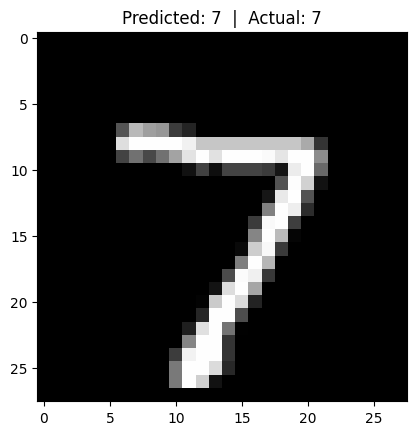

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

img = images[0].unsqueeze(0).to(device)

transformer.eval()
with torch.no_grad():
    output = transformer(img)
    pred = torch.argmax(output, dim=1)

plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Predicted: {pred.item()}  |  Actual: {labels[0].item()}")
plt.show()